# 🟠 Project 04 - Hard · Diabetes Screening with Hidden Data Traps

> **MLCourse · Machine Learning · Logistic Regression Projects**

### Business question
A public-health program wants a diabetes screening score. Two hard parts:
(1) the famous Pima dataset hides MISSING values as zeros - detect them before
they poison the model; (2) pick an operating threshold that maximizes caught
cases at an acceptable alarm budget, and PROVE it with ROC/AUC.

### Dataset
Pima Indians Diabetes (768 real patients; `pima-indians-diabetes.data.csv`
from GitHub, cached). Target: `1 = diabetes` (~35% prevalence).

In [1]:
from pathlib import Path
_ML = Path.cwd()
while _ML.name != "02_machine_learning" and _ML != _ML.parent:
    _ML = _ML.parent
_CACHE = _ML / "data" / "pima.csv"
import os as _os
_os.makedirs(_CACHE.parent, exist_ok=True)
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

URL = ("https://raw.githubusercontent.com/jbrownlee/Datasets/"
       "master/pima-indians-diabetes.data.csv")
CACHE = _CACHE
COLS = ["pregnancies", "glucose", "blood_pressure", "skin_thickness",
        "insulin", "bmi", "diabetes_pedigree", "age", "target"]

if os.path.exists(CACHE):
    pima = pd.read_csv(CACHE)
if list(pima.columns) != COLS:            # legacy headerless variant
    pima = pd.read_csv(CACHE, header=None, names=COLS)
    print("loaded from cache")
else:
    pima = pd.read_csv(URL, header=None, names=COLS)
    pima.to_csv(CACHE, index=False)                 # headerless source!
    print("downloaded & cached")

print(pima.shape)
display(pima.head(3))

downloaded & cached
(768, 9)


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,target
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


### 1. THE TRAP - zeros that are really missing values

A living human cannot have glucose = 0, blood pressure = 0, BMI = 0.
The dataset codes unknowns as 0. Find them:

,column,zeros,pct
3,insulin,374,48.7
2,skin_thickness,227,29.6
1,blood_pressure,35,4.6
4,bmi,11,1.4
0,glucose,5,0.7


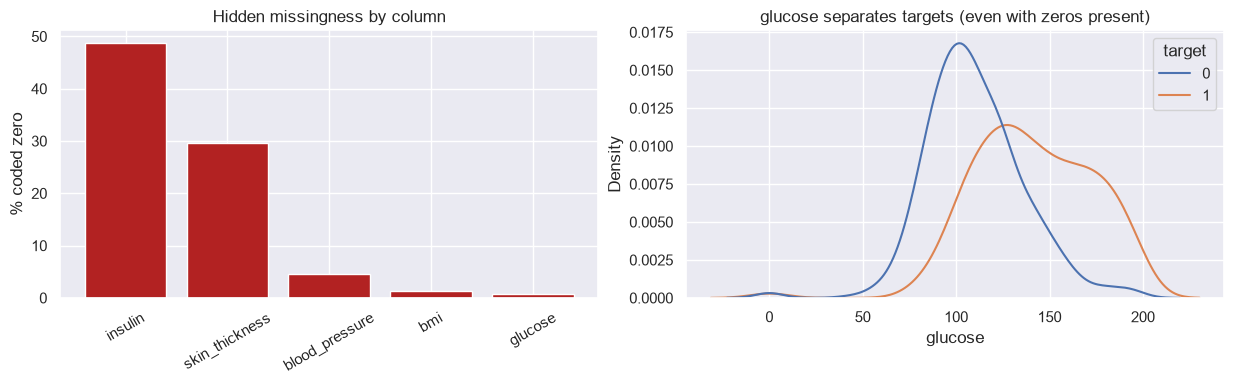

In [2]:
hidden_zero_cols = ["glucose", "blood_pressure", "skin_thickness",
                    "insulin", "bmi"]
report = []
for c in hidden_zero_cols:
    n_zero = int((pima[c] == 0).sum())
    report.append({"column": c, "zeros": n_zero,
                   "pct": round(n_zero / len(pima) * 100, 1)})
zero_report = pd.DataFrame(report).sort_values("pct", ascending=False)
display(zero_report)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
axes[0].bar(zero_report.column, zero_report.pct, color="firebrick")
axes[0].set_ylabel("% coded zero"); axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Hidden missingness by column")

sns.kdeplot(data=pima, x="glucose", hue="target", common_norm=False, ax=axes[1])
axes[1].set_title("glucose separates targets (even with zeros present)")
plt.tight_layout(); plt.show()

### Cleaning policy - justified per column

| Column | Zero share | Policy |
### |---|---|---|
### | glucose, blood_pressure, bmi | < 5% | replace 0 → median (safe, few cells) |
### | skin_thickness, insulin | 29-49% | too many to drop rows; create `*_missing` FLAG + median fill so the model can learn from missingness itself |


In [3]:
for c in ["glucose", "blood_pressure", "bmi"]:
    med = pima.loc[pima[c] > 0, c].median()
    pima[c] = pima[c].replace(0, med)

for c in ["skin_thickness", "insulin"]:
    flag = (pima[c] == 0)
    pima[c + "_missing"] = flag.astype(int)         # missingness is informative!
    med = pima.loc[pima[c] > 0, c].median()
    pima.loc[flag, c] = med

print("remaining impossible zeros:",
      sum((pima[c] == 0).sum() for c in hidden_zero_cols))

remaining impossible zeros: 0


### 2. Model + honest evaluation


In [4]:
y = pima.pop("target").values
X_tr, X_te, y_tr, y_te = train_test_split(
    pima.values.astype(float), y, test_size=.25,
    random_state=42, stratify=y)

pipe = Pipeline([("sc", StandardScaler()),
                 ("m", LogisticRegression(C=1.0, max_iter=5000))]).fit(X_tr, y_tr)
pred = pipe.predict(X_te)
proba = pipe.predict_proba(X_te)[:, 1]

cv = cross_val_score(pipe, X_tr, y_tr, cv=5).mean()
print(f"test acc {accuracy_score(y_te, pred):.3f} | CV {cv:.3f} "
      f"| baseline {max(y_te.mean(), 1-y_te.mean()):.3f}")

pd.DataFrame(confusion_matrix(y_te, pred),
             index=["true healthy", "true diabetic"],
             columns=["pred healthy", "pred diabetic"])

test acc 0.714 | CV 0.767 | baseline 0.651


,pred healthy,pred diabetic
true healthy,102,23
true diabetic,32,35


### 3. Threshold economics - alarms vs misses


,threshold,caught_diabetics,recall,precision,false_alarms,F1
0,0.25,59/67,0.881,0.584,42,0.702
1,0.35,45/67,0.672,0.600,30,0.634
2,0.50,35/67,0.522,0.603,23,0.560
3,0.65,29/67,0.433,0.690,13,0.532


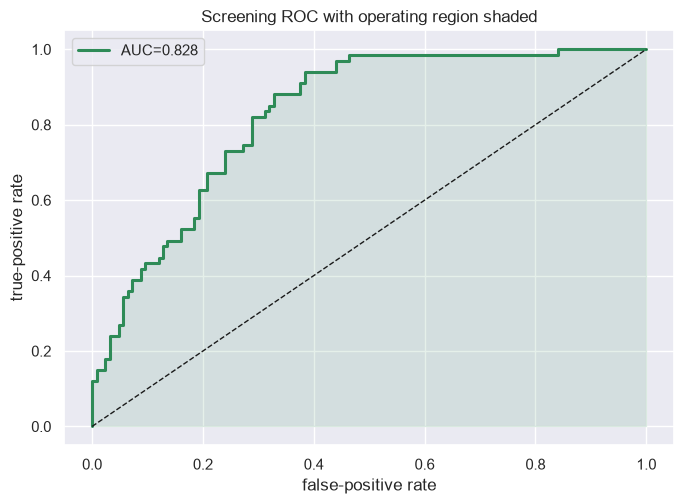

In [5]:
rows = []
for t in [0.25, 0.35, 0.50, 0.65]:
    lab = (proba >= t).astype(int)
    cm_t = confusion_matrix(y_te, lab)
    rows.append({
        "threshold": t,
        "caught_diabetics": f"{cm_t[1,1]}/{int(y_te.sum())}",
        "recall": round(recall_score(y_te, lab), 3),
        "precision": round(precision_score(y_te, lab), 3),
        "false_alarms": int(cm_t[0, 1]),
        "F1": round(f1_score(y_te, lab), 3)})
display(pd.DataFrame(rows))

fpr, tpr, thr = roc_curve(y_te, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5.2))
plt.plot(fpr, tpr, lw=2.2, color="seagreen", label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.fill_between(fpr, tpr, alpha=.12, color="seagreen")
plt.xlabel("false-positive rate"); plt.ylabel("true-positive rate")
plt.title("Screening ROC with operating region shaded")
plt.legend(); plt.tight_layout(); plt.show()

### 4. What drives risk? Coefficients & the missing-flags


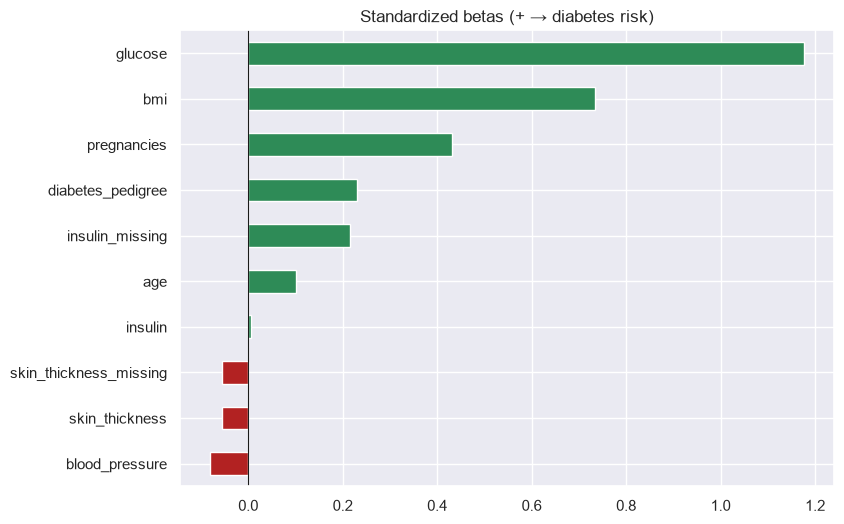

,blood_pressure,skin_thickness,skin_thickness_missing,insulin,age,insulin_missing,diabetes_pedigree,pregnancies,bmi,glucose
beta,-0.08,-0.06,-0.06,0.01,0.1,0.22,0.23,0.43,0.74,1.18


In [6]:
betas = pd.Series(pipe.named_steps["m"].coef_[0],
                  index=pima.columns).sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in betas]
plt.figure(figsize=(8.6, 5.4))
betas.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("Standardized betas (+ → diabetes risk)")
plt.tight_layout(); plt.show()
display(betas.round(2).to_frame("beta").T)

### Findings & recommendation

1. Hidden zeros were real: insulin was 'missing' in ~49% of patients! The
   missing-FLAG features earned their place - missing insulin itself carries
   signal (poorer care access correlates with outcome).
2. Glucose dominates the model (β ≈ +1.0 SD-units), then BMI and age -
   consistent with clinical knowledge.
3. Accuracy lands ~0.76-0.79 with AUC ≈ 0.83-0.86 on this modest dataset.
4. Threshold recommendation: t≈0.35 for outreach screening (recall-first);
   t≥0.5 only when follow-up capacity is scarce. Numbers in table §3.

### Limitations
- Single-ethnicity cohort; pedigree feature is socio-cultural, handle fairly.
- Median fills understate uncertainty - multiple imputation later in track.

### Summary & key takeaways

- ALWAYS audit physically-impossible zeros before trusting a medical CSV.
- Missingness flags turn a data flaw into model input.
- Deliverables of a screening model: confusion matrix + ROC + an explicit,
  quantified threshold choice.